# CDC PLACES EDA

This notebook:
1. **Loads** CDC PLACES data at the **ZCTA** (ZIP Code Tabulation Area) level using the **CDCPLACES R package**.
2. **Converts** the data to a **one-ZCTA-per-row** format (analysis-ready) in Python.
3. Runs **basic exploratory data analysis** (EDA) in Python.

Requires: R with `CDCPLACES` installed, and Python with `rpy2`, `pandas`, `matplotlib`, `seaborn`.

In [2]:
# Python setup: rpy2 (R from Python), pandas, and EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Install rpy2 if missing (run once). If you still get ModuleNotFoundError, restart kernel and run again.
#%pip install rpy2 -q

# R <-> pandas conversion (modern rpy2 API; avoid deprecated activate())
from rpy2.robjects import pandas2ri, default_converter
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

# Use this when converting R data.frames to pandas (see next cell):
#   with localconverter(default_converter + pandas2ri.converter):
#       df = pandas2ri.rpy2py(r_object)

print("Python and rpy2 ready.")

Python and rpy2 ready.


## 1. Load ZCTA data via R (CDCPLACES)

We use the CDCPLACES R package from Python via `rpy2`. Adjust `states` and `measures` to control which ZCTAs and health measures are pulled.

In [3]:
# Load the CDCPLACES R package and fetch ZCTA-level data
import os
import tempfile
from rpy2.robjects import r
from rpy2.robjects.vectors import StrVector
from rpy2.robjects.packages import importr

# Ensure CDCPLACES is loaded in R (install in R first if needed: install.packages("CDCPLACES"))
cdcplaces = importr("CDCPLACES")

# Configuration: state(s) and measure(s) to pull
# For ZCTA, use state to filter (no county filter). Use measure = NULL to get all measures (slower).
states = ["CA"]  # e.g. ["CA"], ["CA", "NY"], or one state for faster runs
measures = ["CASTHMA", "COPD", "OBESITY", "DIABETES"]  # example; use None for all
release = "2023"

# Build R call: get_places(geography = "zcta", state = ..., measure = ..., release = ..., geometry = FALSE)
r.assign("states_r", StrVector(states))
r.assign("measures_r", StrVector(measures))
r.assign("release_r", release)

# get_places(geography = "zcta", state = c("CA"), measure = c("CASTHMA", "COPD", ...), release = "2023", geometry = FALSE)
r('places_zcta <- get_places(geography = "zcta", state = states_r, measure = measures_r, release = release_r, geometry = FALSE)')

# Avoid rpy2 conversion issues (coordinates/numpy): have R write CSV, Python reads it
tmp_csv = os.path.join(tempfile.gettempdir(), "places_zcta_r.csv")
r.assign("tmp_path", tmp_csv)
r('''
if ("sf" %in% class(places_zcta)) {
  if (requireNamespace("sf", quietly = TRUE)) places_zcta <- sf::st_drop_geometry(places_zcta)
}
# Keep only atomic columns (no list/geometry) so write.csv works
atomic <- sapply(places_zcta, is.atomic)
places_zcta <- places_zcta[, atomic, drop = FALSE]
write.csv(places_zcta, tmp_path, row.names = FALSE)
''')

places_long = pd.read_csv(tmp_csv)
try:
    os.remove(tmp_csv)
except OSError:
    pass

print("Raw data (long: one row per ZCTA × measure):")
print(places_long.shape)
places_long.head(10)

Raw data (long: one row per ZCTA × measure):
(6928, 16)


,year,locationname,datasource,category,measure,data_value_unit,data_value_type,data_value,low_confidence_limit,high_confidence_limit,totalpopulation,locationid,categoryid,measureid,datavaluetypeid,short_question_text
0,2021,89010,BRFSS,Health Outcomes,Current asthma among adults aged >=18 years,%,Crude prevalence,10.3,9.1,11.6,415,89010,HLTHOUT,CASTHMA,CrdPrv,Current Asthma
1,2021,89010,BRFSS,Health Outcomes,Chronic obstructive pulmonary disease among ad...,%,Crude prevalence,11.0,9.3,13.1,415,89010,HLTHOUT,COPD,CrdPrv,COPD
2,2021,89010,BRFSS,Health Outcomes,Diagnosed diabetes among adults aged >=18 years,%,Crude prevalence,14.4,12.3,16.6,415,89010,HLTHOUT,DIABETES,CrdPrv,Diabetes
3,2021,89010,BRFSS,Health Outcomes,Obesity among adults aged >=18 years,%,Crude prevalence,36.3,28.5,44.6,415,89010,HLTHOUT,OBESITY,CrdPrv,Obesity
4,2021,89019,BRFSS,Health Outcomes,Current asthma among adults aged >=18 years,%,Crude prevalence,9.3,8.2,10.5,2673,89019,HLTHOUT,CASTHMA,CrdPrv,Current Asthma
5,2021,89019,BRFSS,Health Outcomes,Chronic obstructive pulmonary disease among ad...,%,Crude prevalence,7.6,6.3,9.0,2673,89019,HLTHOUT,COPD,CrdPrv,COPD
6,2021,89019,BRFSS,Health Outcomes,Diagnosed diabetes among adults aged >=18 years,%,Crude prevalence,11.3,9.8,12.8,2673,89019,HLTHOUT,DIABETES,CrdPrv,Diabetes
7,2021,89019,BRFSS,Health Outcomes,Obesity among adults aged >=18 years,%,Crude prevalence,30.7,26.4,35.5,2673,89019,HLTHOUT,OBESITY,CrdPrv,Obesity
8,2021,89060,BRFSS,Health Outcomes,Current asthma among adults aged >=18 years,%,Crude prevalence,10.6,9.3,12.1,10227,89060,HLTHOUT,CASTHMA,CrdPrv,Current Asthma
9,2021,89060,BRFSS,Health Outcomes,Chronic obstructive pulmonary disease among ad...,%,Crude prevalence,12.2,10.6,14.0,10227,89060,HLTHOUT,COPD,CrdPrv,COPD


## 2. Reshape to one ZCTA per row

The API returns one row per (ZCTA, measure). We pivot so each measure becomes a column and each row is a single ZCTA.

In [4]:
# Inspect column names (CDCPLACES may use slightly different names by release)
print("Columns:", list(places_long.columns))

# Detect column roles: ZCTA/geo id, measure id, and data value
def first_in(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

id_col = first_in(places_long.columns, ["LocationName", "ZCTA", "zcta", "locationname", "ZCTA5"])
measure_col = first_in(places_long.columns, ["MeasureId", "measureid", "Measure"])
value_col = first_in(places_long.columns, ["Data_Value", "data_value", "DataValue"])

# Fallback: if names differ, infer from position (long format often: geo, measure, value)
if id_col is None or measure_col is None or value_col is None:
    cols = list(places_long.columns)
    if id_col is None and len(cols) >= 1:
        id_col = cols[0]
    if measure_col is None and len(cols) >= 2:
        measure_col = cols[1]
    if value_col is None and len(cols) >= 3:
        value_col = cols[2]

print(f"Using: id_col={id_col!r}, measure_col={measure_col!r}, value_col={value_col!r}")

Columns: ['year', 'locationname', 'datasource', 'category', 'measure', 'data_value_unit', 'data_value_type', 'data_value', 'low_confidence_limit', 'high_confidence_limit', 'totalpopulation', 'locationid', 'categoryid', 'measureid', 'datavaluetypeid', 'short_question_text']
Using: id_col='locationname', measure_col='measureid', value_col='data_value'


In [5]:
# Pivot to one row per ZCTA; each measure becomes a column
# Keep state/geo identifiers if present for merging later
index_cols = [id_col]
if "StateAbbr" in places_long.columns:
    index_cols.insert(0, "StateAbbr")
elif "state_abbr" in places_long.columns:
    index_cols.insert(0, "state_abbr")

# Ensure we only use columns that exist
index_cols = [c for c in index_cols if c in places_long.columns]

places_wide = places_long.pivot_table(
    index=index_cols,
    columns=measure_col,
    values=value_col,
    aggfunc="first"  # one value per (ZCTA, measure)
).reset_index()

# Rename index-like column to a clear name for analysis
places_wide = places_wide.rename(columns={id_col: "ZCTA"}) if id_col != "ZCTA" else places_wide

print("One ZCTA per row (analysis-ready):")
print(places_wide.shape)
places_wide.head(10)

One ZCTA per row (analysis-ready):
(1732, 5)


measureid,ZCTA,CASTHMA,COPD,DIABETES,OBESITY
0,89010,10.3,11.0,14.4,36.3
1,89019,9.3,7.6,11.3,30.7
2,89060,10.6,12.2,15.3,40.0
3,89061,10.0,9.6,12.8,37.1
4,89439,9.5,7.1,10.0,26.5
5,90001,11.3,5.9,14.4,37.2
6,90002,12.0,6.4,14.8,38.0
7,90003,11.9,6.4,14.7,38.5
8,90004,9.0,4.2,11.7,27.2
9,90005,9.0,4.5,13.1,27.0


## 3. Basic EDA

Summary statistics, missing values, and distributions.

In [6]:
# Summary: shape, dtypes, missing
print("Shape:", places_wide.shape)
print("\nDtypes:")
print(places_wide.dtypes)
print("\nMissing values per column:")
print(places_wide.isna().sum())
print("\nBasic describe (numeric):")
places_wide.describe()

Shape: (1732, 5)

Dtypes:
measureid
ZCTA          int64
CASTHMA     float64
COPD        float64
DIABETES    float64
OBESITY     float64
dtype: object

Missing values per column:
measureid
ZCTA        0
CASTHMA     0
COPD        0
DIABETES    0
OBESITY     0
dtype: int64

Basic describe (numeric):


measureid,ZCTA,CASTHMA,COPD,DIABETES,OBESITY
count,1732.000000,1732.000000,1732.000000,1732.000000,1732.000000
mean,93656.882217,9.796305,6.124654,10.757217,29.757564
std,1825.782374,0.982450,2.235197,2.823161,5.965994
min,89010.000000,6.400000,1.100000,0.900000,13.400000
25%,92255.500000,9.100000,4.500000,8.875000,25.375000
50%,93661.000000,9.800000,5.700000,10.600000,30.100000
75%,95377.500000,10.500000,7.500000,12.600000,33.700000
max,97635.000000,13.900000,17.500000,33.100000,48.700000


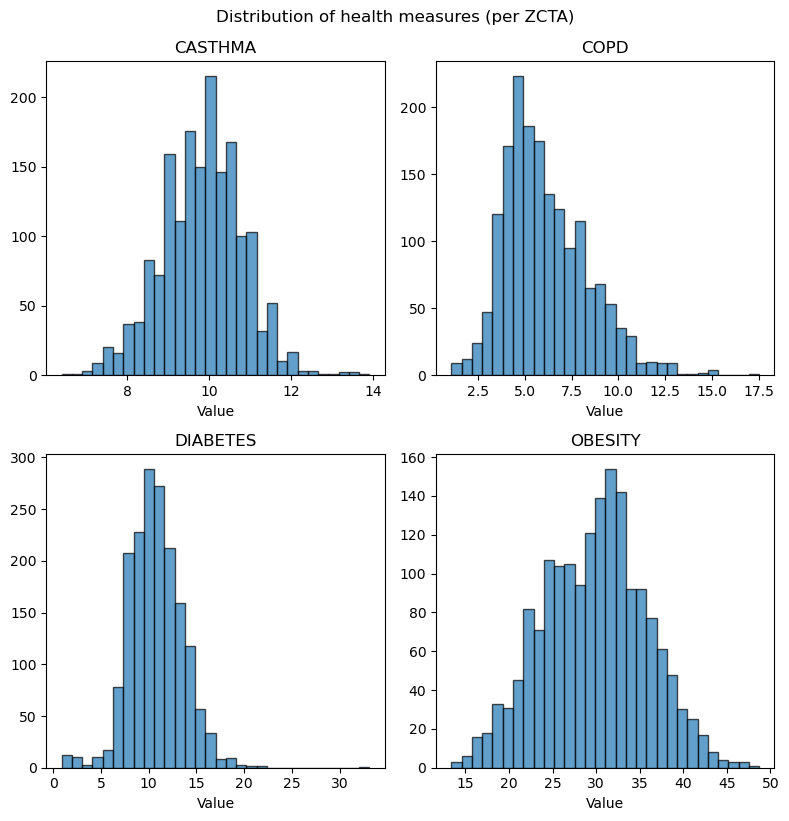

In [7]:
# Distributions: histograms for each measure (numeric columns only)
measure_cols = [c for c in places_wide.columns if c not in ["ZCTA", "StateAbbr", "state_abbr"] and places_wide[c].dtype in ["float64", "int64"]]
if not measure_cols:
    measure_cols = [c for c in places_wide.columns if places_wide[c].dtype in ["float64", "int64"]]

n = len(measure_cols)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(4 * ((n + 1) // 2), 4 * 2))
if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()
for i, col in enumerate(measure_cols):
    axes[i].hist(places_wide[col].dropna(), bins=30, edgecolor="black", alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.suptitle("Distribution of health measures (per ZCTA)", y=1.02)
plt.show()

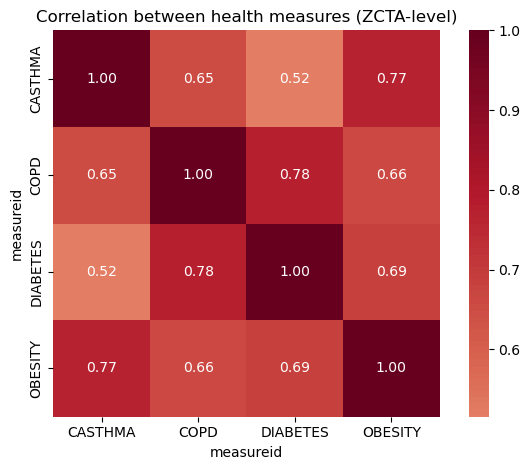

In [8]:
# Correlation matrix of health measures (if multiple numeric columns)
if len(measure_cols) >= 2:
    corr = places_wide[measure_cols].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
    plt.title("Correlation between health measures (ZCTA-level)")
    plt.tight_layout()
    plt.show()
else:
    print("Need at least 2 numeric measure columns for correlation plot.")

## 4. EDA: Asthma and COPD outcomes

Focusing on **asthma** (CASTHMA = current asthma among adults) and **COPD** (chronic obstructive pulmonary disease)—two respiratory outcomes often used as proxies for environmental health in pesticide-exposure research.

In [9]:
# Subset to asthma and COPD columns (ensure they exist)
resp_cols = [c for c in ["CASTHMA", "COPD"] if c in places_wide.columns]
resp_df = places_wide[["ZCTA"] + resp_cols].dropna() if resp_cols else pd.DataFrame()
if len(resp_cols) < 2:
    print("CASTHMA or COPD not in places_wide. Columns:", list(places_wide.columns))
else:
    print("Asthma (CASTHMA) and COPD — summary by ZCTA:")
    print(resp_df[resp_cols].describe())
    print("\nCorrelation (asthma vs COPD):", resp_df["CASTHMA"].corr(resp_df["COPD"]).round(3))

Asthma (CASTHMA) and COPD — summary by ZCTA:
measureid      CASTHMA         COPD
count      1732.000000  1732.000000
mean          9.796305     6.124654
std           0.982450     2.235197
min           6.400000     1.100000
25%           9.100000     4.500000
50%           9.800000     5.700000
75%          10.500000     7.500000
max          13.900000    17.500000

Correlation (asthma vs COPD): 0.652


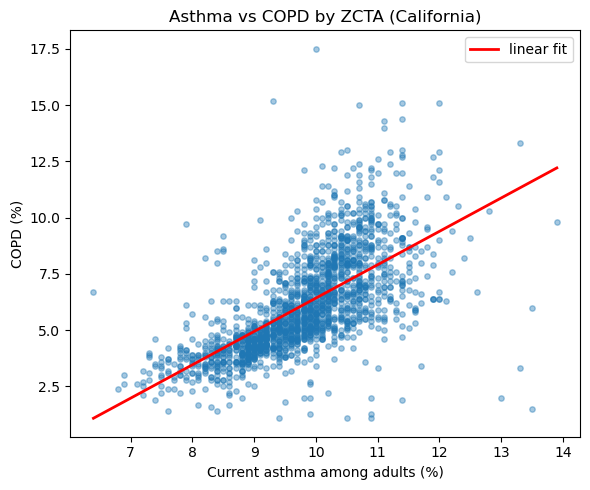

In [10]:
# Scatter: Asthma vs COPD (ZCTA-level)
if len(resp_cols) == 2:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(resp_df["CASTHMA"], resp_df["COPD"], alpha=0.4, s=15)
    z = np.polyfit(resp_df["CASTHMA"], resp_df["COPD"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(resp_df["CASTHMA"].min(), resp_df["CASTHMA"].max(), 100)
    ax.plot(x_line, p(x_line), "r-", linewidth=2, label="linear fit")
    ax.set_xlabel("Current asthma among adults (%)")
    ax.set_ylabel("COPD (%)")
    ax.set_title("Asthma vs COPD by ZCTA (California)")
    ax.legend()
    plt.tight_layout()
    plt.show()

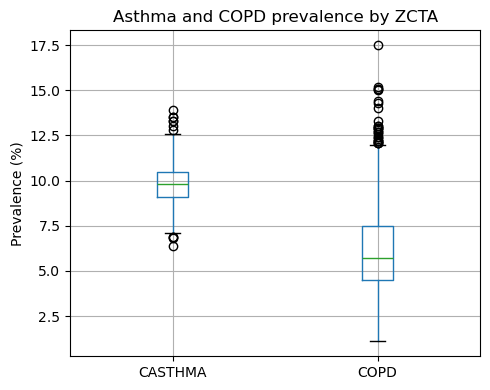

In [11]:
# Distribution comparison: side-by-side boxplots
if len(resp_cols) == 2:
    fig, ax = plt.subplots(figsize=(5, 4))
    resp_df[resp_cols].boxplot(ax=ax)
    ax.set_ylabel("Prevalence (%)")
    ax.set_title("Asthma and COPD prevalence by ZCTA")
    plt.tight_layout()
    plt.show()

In [ ]:
# ZCTAs in top quartile for both asthma and COPD (high respiratory burden)
if len(resp_cols) == 2:
    q75_a = resp_df["CASTHMA"].quantile(0.75)
    q75_c = resp_df["COPD"].quantile(0.75)
    high_both = resp_df[(resp_df["CASTHMA"] >= q75_a) & (resp_df["COPD"] >= q75_c)]
    print(f"ZCTAs in top quartile for BOTH asthma and COPD: {len(high_both)}")
    print(f"  Asthma ≥ {q75_a:.1f}%, COPD ≥ {q75_c:.1f}%")
    print("\nExample ZCTAs (high respiratory burden):")
    print(high_both.nlargest(10, "CASTHMA")[["ZCTA", "CASTHMA", "COPD"]])

In [16]:
# Optional: save analysis-ready data for use in other scripts
# out_path = "places_zcta_one_per_row.csv"
# places_wide.to_csv(out_path, index=False)
# print(f"Saved to {out_path}")

# Final view: analysis-ready dataframe (one ZCTA per row)
places_wide

measureid,ZCTA,CASTHMA,COPD,DIABETES,OBESITY
0,89010,10.3,11.0,14.4,36.3
1,89019,9.3,7.6,11.3,30.7
2,89060,10.6,12.2,15.3,40.0
3,89061,10.0,9.6,12.8,37.1
4,89439,9.5,7.1,10.0,26.5
...,...,...,...,...,...
1727,96146,9.2,4.6,7.1,26.2
1728,96148,9.4,5.2,8.4,28.6
1729,96150,9.9,5.6,8.7,30.0
1730,96161,9.4,4.4,7.0,27.0


## 5. State-level data for COPD and Asthma

PLACES does not provide state as a geography. To get **state-level** estimates, we pull **county**-level data for CASTHMA and COPD, then aggregate by state (e.g. mean across counties). Run the cell below to fetch county data and build a one-row-per-state table.

In [ ]:
# Pull COUNTY-level PLACES data for COPD and Asthma (then we aggregate to state)
import os
import tempfile
from rpy2.robjects import r
from rpy2.robjects.vectors import StrVector
from rpy2.robjects.packages import importr

cdcplaces = importr("CDCPLACES")
r.assign("measures_r", StrVector(["CASTHMA", "COPD"]))
r.assign("release_r", "2023")

# geography = "county", state = NULL gets all US counties (or specify states_r for a subset)
r('places_county <- get_places(geography = "county", state = NULL, measure = measures_r, release = release_r, geometry = FALSE)')

# Keep only atomic columns and write to CSV (avoids rpy2 conversion issues)
tmp_csv = os.path.join(tempfile.gettempdir(), "places_county_r.csv")
r.assign("tmp_path", tmp_csv)
r('''
atomic <- sapply(places_county, is.atomic)
places_county <- places_county[, atomic, drop = FALSE]
write.csv(places_county, tmp_path, row.names = FALSE)
''')

county_df = pd.read_csv(tmp_csv)
try:
    os.remove(tmp_csv)
except OSError:
    pass

# Standardize column names (API may return mixed case)
county_df.columns = [c.strip().lower().replace(" ", "_") for c in county_df.columns]
# Common names: stateabbr, locationname, measureid, data_value
state_col = "stateabbr" if "stateabbr" in county_df.columns else [c for c in county_df.columns if "state" in c][0]
loc_col = "locationname" if "locationname" in county_df.columns else [c for c in county_df.columns if "location" in c or "county" in c][0]
measure_col = "measureid" if "measureid" in county_df.columns else [c for c in county_df.columns if "measure" in c][0]
value_col = "data_value" if "data_value" in county_df.columns else [c for c in county_df.columns if "value" in c and "conf" not in c][0]

print("County-level data shape:", county_df.shape)
county_df.head()

In [ ]:
# Reshape to one row per county (CASTHMA and COPD as columns), then aggregate to state
county_wide = county_df.pivot_table(
    index=[state_col, loc_col],
    columns=measure_col,
    values=value_col,
    aggfunc="first"
).reset_index()

# State-level: mean prevalence across counties in each state
state_level = county_wide.groupby(state_col)[["CASTHMA", "COPD"]].mean().reset_index()
state_level.columns = ["State", "CASTHMA", "COPD"]

print("State-level COPD and Asthma (mean prevalence across counties):")
print(state_level.shape)
display(state_level.sort_values("CASTHMA", ascending=False).head(15))

---

**Next steps:** Use `places_wide` in other analyses (e.g. merge with pesticide exposure by ZCTA). Uncomment the save cell above to export `places_zcta_one_per_row.csv`. To pull more states or measures, edit `states` and `measures` in the first data-load cell and re-run.